# Pitcher Fatigue Risk Index - Spencer Strider 2024 Injury
### An early-warning system for elbow and shoulder breakdown risk, built from public Statcast data

Injuries usually look sudden, but the warning signs (lower velocity, dropping spin rate, a shifting release point) often show up in the data weeks before anything happens. This tool scores every start against a pitcher's own recent baseline across velocity, spin rate, release point, and workload, and turns that into a single Fatigue Risk Index per outing.

I tested it against one real case, Spencer Strider's 2024 UCL injury, and it flagged elevated risk in his final two starts before he went down. One case doesn't prove the model works, so I'm treating this as an early-warning signal worth exploring further, not a finished predictive tool.

Stack: Python, pybaseball, Statcast, pandas, numpy, matplotlib


In [ ]:
!pip install pybaseball -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pybaseball import statcast_pitcher, playerid_lookup

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.6/455.6 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.5 MB/s eta 0:00:00


## 1. Data pull

This covers Spencer Strider's full 2023 season, when he was healthy all year, plus his two 2024 starts before the injury. The 2023 games give the model enough history to learn his normal baseline, then the 2024 starts test whether the index picked up anything unusual in the lead-up to a real injury.



In [ ]:
PITCHERS = {
    "Spencer Strider": 675911,
}

START_DATE = "2023-03-30"
END_DATE   = "2024-04-05"

def pull_pitcher_data(name, mlbam_id, start, end):
    df = statcast_pitcher(start, end, mlbam_id)
    df["pitcher_name"] = name
    return df

raw_frames = [pull_pitcher_data(name, pid, START_DATE, END_DATE) for name, pid in PITCHERS.items()]
statcast_raw = pd.concat(raw_frames, ignore_index=True)
statcast_raw["game_date"] = pd.to_datetime(statcast_raw["game_date"])
statcast_raw = statcast_raw.sort_values(["pitcher_name", "game_date"])
statcast_raw.shape


Gathering Player Data


(3657, 120)

## 2. Per-appearance feature extraction

Pitch-level data gets collapsed into one row per outing: average and max fastball velocity, average spin rate, average release point, and total pitch count. I used fastball-family pitches (four-seam, sinker, cutter) for the velocity and spin numbers, since those are the pitches thrown hardest and most often, making them the clearest signal of arm fatigue.


In [ ]:
FASTBALL_TYPES = ["FF", "SI", "FC"]

def build_appearance_features(df):
    fb = df[df["pitch_type"].isin(FASTBALL_TYPES)].copy()

    agg = fb.groupby(["pitcher_name", "game_date"]).agg(
        avg_velo=("release_speed", "mean"),
        max_velo=("release_speed", "max"),
        avg_spin=("release_spin_rate", "mean"),
        avg_rel_x=("release_pos_x", "mean"),
        avg_rel_z=("release_pos_z", "mean"),
        n_fastballs=("release_speed", "count"),
    ).reset_index()

    total_pitches = df.groupby(["pitcher_name", "game_date"]).size().rename("total_pitches")
    agg = agg.merge(total_pitches, on=["pitcher_name", "game_date"])

    return agg.sort_values(["pitcher_name", "game_date"]).reset_index(drop=True)

appearances = build_appearance_features(statcast_raw)
appearances["game_date"] = appearances["game_date"].dt.date

def highlight_injury_game(row):
    if row["game_date"] == pd.Timestamp("2024-04-05").date():
        return ["background-color: #f8d7da; color: #000000; font-weight: bold"] * len(row)
    return [""] * len(row)

appearances.style.format({
    "avg_velo": "{:.2f}",
    "max_velo": "{:.2f}",
    "avg_spin": "{:.2f}",
    "avg_rel_x": "{:.2f}",
    "avg_rel_z": "{:.2f}",
}).apply(highlight_injury_game, axis=1)

,pitcher_name,game_date,avg_velo,max_velo,avg_spin,avg_rel_x,avg_rel_z,n_fastballs,total_pitches
0,Spencer Strider,2023-04-01,97.54,99.60,2418.73,-1.92,5.91,62,96
1,Spencer Strider,2023-04-06,96.76,99.20,2402.93,-1.97,5.98,61,101
2,Spencer Strider,2023-04-12,97.07,99.60,2417.59,-1.96,5.93,64,98
3,Spencer Strider,2023-04-18,97.45,99.60,2348.31,-1.95,5.82,54,98
4,Spencer Strider,2023-04-24,97.04,99.20,2397.00,-2.01,6.00,58,101
5,Spencer Strider,2023-05-01,96.55,98.70,2409.90,-1.96,5.83,64,107
6,Spencer Strider,2023-05-06,96.86,98.70,2346.26,-2.07,5.99,57,95
7,Spencer Strider,2023-05-12,97.03,98.80,2442.00,-2.04,5.84,69,110
8,Spencer Strider,2023-05-17,96.98,99.10,2344.02,-2.06,5.87,58,88
9,Spencer Strider,2023-05-23,97.27,99.10,2376.79,-2.11,6.00,53,106


## 3. Fatigue signal engineering

Each start gets scored against the pitcher's own trailing 5-outing baseline, not a league average, since normal velocity and spin vary a lot from pitcher to pitcher. What matters is how far he's drifted from his own normal, not the league's.

Release point drift combines how much his horizontal and vertical release point moved, since when a pitcher compensates for something mechanically, it usually shows up in both directions at once. Workload is tracked as a rolling pitch-count z-score against his season-to-date average, which picks up short-rest stretches or unusually heavy usage.


In [ ]:
def add_rolling_baselines(df, window=5):
    df = df.copy()
    grouped = df.groupby("pitcher_name")

    for col in ["avg_velo", "avg_spin", "avg_rel_x", "avg_rel_z"]:
        df[f"{col}_baseline_mean"] = grouped[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=3).mean()
        )
        df[f"{col}_baseline_std"] = grouped[col].transform(
            lambda s: s.shift(1).rolling(window, min_periods=3).std()
        )
        df[f"{col}_zscore"] = (df[col] - df[f"{col}_baseline_mean"]) / df[f"{col}_baseline_std"]

    return df

appearances = add_rolling_baselines(appearances)
appearances["release_drift_zscore"] = np.sqrt(
    appearances["avg_rel_x_zscore"]**2 + appearances["avg_rel_z_zscore"]**2
)


In [ ]:
def add_workload_features(df, appearances_lookback=3, offseason_gap_days=45):
    df = df.copy()
    grouped = df.groupby("pitcher_name")

    df["days_since_last_appearance"] = grouped["game_date"].diff().dt.days
    df["pitches_trailing_3_starts"] = grouped["total_pitches"].transform(
        lambda s: s.shift(1).rolling(appearances_lookback, min_periods=1).sum()
    )

    season_avg = grouped["total_pitches"].transform(lambda s: s.shift(1).expanding().mean())
    season_std = grouped["total_pitches"].transform(lambda s: s.shift(1).expanding().std())
    df["workload_zscore"] = (df["total_pitches"] - season_avg) / season_std

    # flag any start whose baseline includes a long layoff (e.g. an offseason)
    df["follows_long_layoff"] = df["days_since_last_appearance"] > offseason_gap_days

    return df

appearances["game_date"] = pd.to_datetime(appearances["game_date"])
appearances = add_workload_features(appearances)

## 4. Composite Fatigue Risk Index

The four signals get combined into one weighted score. Velocity and spin decline carry the most weight, since research points to those as the earliest signs of arm fatigue. Release drift and workload spikes count too, but as smaller supporting factors. Only bad movement counts toward risk (a drop in velocity or spin, a rise in drift or workload), so improving in one area never cancels out a problem somewhere else.


In [ ]:
WEIGHTS = {"velo_drop": 0.35, "spin_drop": 0.30, "release_drift": 0.20, "workload_spike": 0.15}

def compute_risk_index(df):
    df = df.copy()
    df["velo_drop_risk"] = (-df["avg_velo_zscore"]).clip(lower=0)
    df["spin_drop_risk"] = (-df["avg_spin_zscore"]).clip(lower=0)
    df["release_drift_risk"] = df["release_drift_zscore"].clip(lower=0)
    df["workload_spike_risk"] = df["workload_zscore"].clip(lower=0)

    df["fatigue_risk_index"] = (
        WEIGHTS["velo_drop"] * df["velo_drop_risk"].fillna(0) +
        WEIGHTS["spin_drop"] * df["spin_drop_risk"].fillna(0) +
        WEIGHTS["release_drift"] * df["release_drift_risk"].fillna(0) +
        WEIGHTS["workload_spike"] * df["workload_spike_risk"].fillna(0)
    )
    return df

appearances = compute_risk_index(appearances)

def color_risk_index(val):
    if val > 3:
        color = "#b30000"
        text = "white"
    elif val > 2:
        color = "#e06666"
        text = "white"
    elif val > 1:
        color = "#f8d7da"
        text = "black"
    else:
        color = ""
        text = ""
    return f"background-color: {color}; color: {text}; font-weight: bold" if color else ""

display_table = appearances[["pitcher_name", "game_date", "fatigue_risk_index"]].sort_values("game_date").copy()
display_table["game_date"] = display_table["game_date"].dt.strftime("%Y-%m-%d")

display_table.style.map(color_risk_index, subset=["fatigue_risk_index"]).format({"fatigue_risk_index": "{:.2f}"})

,pitcher_name,game_date,fatigue_risk_index
0,Spencer Strider,2023-04-01,0.00
1,Spencer Strider,2023-04-06,0.00
2,Spencer Strider,2023-04-12,0.00
3,Spencer Strider,2023-04-18,2.83
4,Spencer Strider,2023-04-24,0.97
5,Spencer Strider,2023-05-01,1.52
6,Spencer Strider,2023-05-06,1.51
7,Spencer Strider,2023-05-12,0.67
8,Spencer Strider,2023-05-17,0.56
9,Spencer Strider,2023-05-23,0.68


## 5. Risk timeline

This chart plots the Fatigue Risk Index across every outing, with a dashed line marking Strider's own top 15% riskiest starts. The shaded gray band shows the gap between his last 2023 start and his first 2024 start, the offseason, so it's clear his 2024 baseline is being built on games from months earlier, not recent ones.

Several 2023 starts crossed the threshold without any injury, including the season's single highest reading (September 6, 2023), so the index isn't purely reactive to season's end. What stands out is that his two most recent starts before the 2024 injury both landed above threshold, though with only one real case, that can't be ruled out as coincidence.


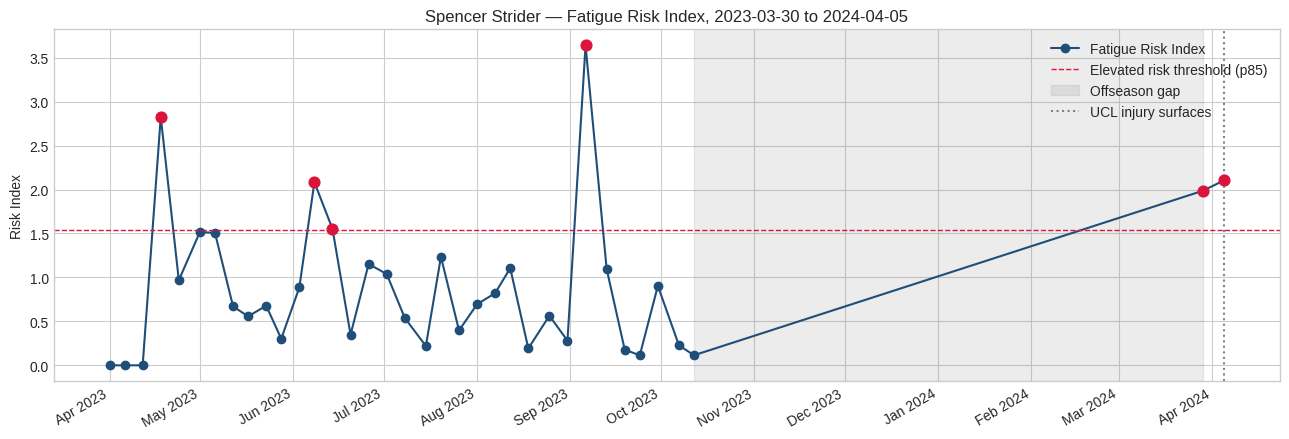

In [ ]:
def plot_risk_timeline(df, pitcher_name, threshold_pct=0.85):
    sub = df[df["pitcher_name"] == pitcher_name].dropna(subset=["fatigue_risk_index"])
    threshold = sub["fatigue_risk_index"].quantile(threshold_pct)

    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.plot(sub["game_date"], sub["fatigue_risk_index"], marker="o", color="#1f4e79", label="Fatigue Risk Index")
    ax.axhline(threshold, color="crimson", linestyle="--", linewidth=1, label=f"Elevated risk threshold (p{int(threshold_pct*100)})")

    elevated = sub[sub["fatigue_risk_index"] >= threshold]
    ax.scatter(elevated["game_date"], elevated["fatigue_risk_index"], color="crimson", zorder=5, s=60)

    # shade the offseason gap so the reader can see the layoff
    layoff_starts = sub[sub["follows_long_layoff"] == True]
    for _, row in layoff_starts.iterrows():
        gap_start = row["game_date"] - pd.Timedelta(days=row["days_since_last_appearance"])
        ax.axvspan(gap_start, row["game_date"], color="gray", alpha=0.15, label="Offseason gap")

    ax.axvline(pd.Timestamp("2024-04-05"), color="gray", linestyle=":", linewidth=1.5, label="UCL injury surfaces")

    ax.set_title(f"{pitcher_name} — Fatigue Risk Index, {START_DATE} to {END_DATE}")
    ax.set_ylabel("Risk Index")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

for name in PITCHERS:
    plot_risk_timeline(appearances, name)

## 6. Case validation — Spencer Strider, 2024 UCL injury

The table below shows exactly what drove those two final scores. Both March 29 and April 5 show negative velocity and spin z-scores, meaning he was throwing slower and spinning the ball less than his own recent average. April 5 in particular stands out (spin dropped over 3 standard deviations below normal), though part of that reading may reflect him already pitching hurt mid-game rather than a clean warning sign beforehand. March 29 is the cleaner case, since nothing was wrong with him yet on that date, and it still shows a real drop in velocity and spin against his baseline.


In [ ]:
KNOWN_IL_STINTS = [
    {"pitcher_name": "Spencer Strider", "il_date": "2024-04-12", "reason": "UCL internal brace surgery (elbow discomfort surfaced April 5, 2024)"},
]

for stint in KNOWN_IL_STINTS:
    sub = appearances[appearances["pitcher_name"] == stint["pitcher_name"]].copy()
    sub["game_date"] = pd.to_datetime(sub["game_date"])
    il_date = pd.to_datetime(stint["il_date"])
    lead_up = sub[sub["game_date"] <= il_date].tail(6)
    print(f"{stint['pitcher_name']} — {stint['reason']}\n")
    print(lead_up[["game_date", "avg_velo_zscore", "avg_spin_zscore",
                    "release_drift_zscore", "fatigue_risk_index"]].to_string(index=False))


Spencer Strider — UCL internal brace surgery (elbow discomfort surfaced April 5, 2024)

 game_date  avg_velo_zscore  avg_spin_zscore  release_drift_zscore  fatigue_risk_index
2023-09-24         0.546228         0.276659              0.567561            0.113512
2023-09-30        -1.332859        -0.035635              2.135268            0.904245
2023-10-07         1.808104         0.189553              1.136761            0.227352
2023-10-12         3.956706         3.381144              0.562501            0.114654
2024-03-29        -1.277387        -1.321276              5.718822            1.987233
2024-04-05        -2.030791        -3.328508              1.983755            2.106080


## 7. Findings

Both of Strider's final two starts registered above his own 85th-percentile risk threshold, driven mainly by velocity and spin decline rather than release drift or workload. March 29 is the cleaner signal, since nothing was physically wrong with him yet on that date and his velocity and spin were already down. April 5 shows an even steeper drop, but part of that reading likely reflects him pitching hurt mid-game rather than a pure warning sign beforehand.

That said, this isn't proof the model works. Several 2023 starts crossed the same threshold with no injury attached, including the single highest reading of the whole sample (September 6, 2023). With one documented case, there's no way to tell whether flagging his last two starts was a real early warning or a coincidence. The index won't predict injuries with certainty, and it was never built to, but it gives a concrete, data-driven way to flag when a pitcher looks different from his own normal, which is exactly the kind of signal a team would want to investigate further rather than ignore.

